In [1]:
#importing required libraries
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
#opening titanic data set which is in csv file
data = pd.read_csv('Titanic-Dataset.csv')
data.head()  #printing first 5 rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df = data[['Pclass', 'Age', 'Sex', 'Survived']].copy() #takin the copy of data and name it as df
print(df.tail())

     Pclass   Age     Sex  Survived
886       2  27.0    male         0
887       1  19.0  female         1
888       3   NaN  female         0
889       1  26.0    male         1
890       3  32.0    male         0


In [4]:
df[['Age']].isnull().sum()  #checking which columns contain empty values and how many empty values

Age    177
dtype: int64

In [5]:
df['Age'].fillna(df['Age'].median(), inplace = True)  #replacing missing age values with median of age to avoid skewing the distribution

In [6]:
df['Sex'] = df['Sex'].map({'male' : 0, 'female': 1})  #mapping 'Sex' values into numeric form for the model

In [7]:
#splitting data X as training (80%) and y as testing(20%)
X = df[['Pclass', 'Age', 'Sex']]
y = df['Survived']

In [8]:
#keeping 20% of data for testing and 80% for training and selecting random data for testing and training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) 
model = DecisionTreeClassifier(max_depth = 3) #use a shallow decision tree(max_depth = 3) to avoid overfitting
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [9]:
#predict y_test on the base of x_test
predictions = model.predict(X_test)  
print(accuracy_score(y_test, predictions))

0.8044692737430168


In [10]:
train_predictions = model.predict(X_train)
#checking accuracy for training and testing
print('Train_accuracy:', accuracy_score(y_train, train_predictions))
print('Test_accuracy:', accuracy_score(y_test, predictions)) #check how well the model performs on unseen test data

Train_accuracy: 0.8103932584269663
Test_accuracy: 0.8044692737430168


In [11]:
#Accuracy_score alone is not enough, so we used confusion_metrix which shows detailed prediction error(TP, TN, FP, FN)
print(classification_report(y_test, predictions)) #this one line is calling precision, recall, f1-score
print(confusion_matrix(y_test, predictions)) #it gives grid 2*2 telling which mistakes model is making instead of just telling how many mistakes model is making
print('AUC:', roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.70      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

[[92 13]
 [22 52]]
AUC: 0.8568211068211068


In [12]:
scores = cross_val_score(model, X, y, cv = 5) #5 fold cross velidation  to measure model stability
print('cv scores:', scores) #result of 5 folds that run above
print('Mean CV accuracy:', scores.mean()) #taking mean of all folds 

cv scores: [0.72067039 0.81460674 0.79213483 0.76404494 0.80337079]
Mean CV accuracy: 0.7789655388864479


In [13]:
#using different models and checking their accuracy
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth = 3),
    'Random Forest': RandomForestClassifier(n_estimators= 100, random_state = 42),
    'Logistic Regression': LogisticRegression(max_iter= 1000)
}
for name, m in models.items():  #looping through dictionery 
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    print(name, '-->', accuracy_score(y_test, preds))

Decision Tree --> 0.8044692737430168
Random Forest --> 0.7932960893854749
Logistic Regression --> 0.8100558659217877


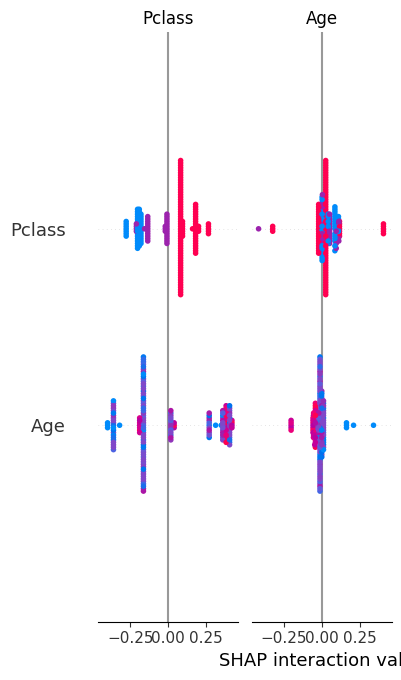

In [15]:
import shap #shap computes how much the feature pushed the prediction up or down from baseline
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)